In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

def f(x):
    return x**2

def grad_f(x):
    return 2 * x

def gradient_descent(starting_point, learning_rate, n_iterations):
    x = starting_point
    x_history = [x]
    
    for _ in range(n_iterations):
        grad = grad_f(x)
        x = x - learning_rate * grad
        x_history.append(x)
    
    return x_history

# Parameters
x0 = 10           # Starting point
lr = 0.1          #
n_iters = 25      

# Run gradient descent
trajectory = gradient_descent(x0, lr, n_iters)

# Prepare data for plotting
x_vals = np.linspace(-12, 12, 400)
y_vals = f(x_vals)
trajectory_y = [f(x) for x in trajectory]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label='f(x) = x²', color='blue')
plt.scatter(trajectory, trajectory_y, color='red')
plt.plot(trajectory, trajectory_y, '--', color='gray', label='Gradient descent path')
plt.title('Gradient Descent on f(x) = x²')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()


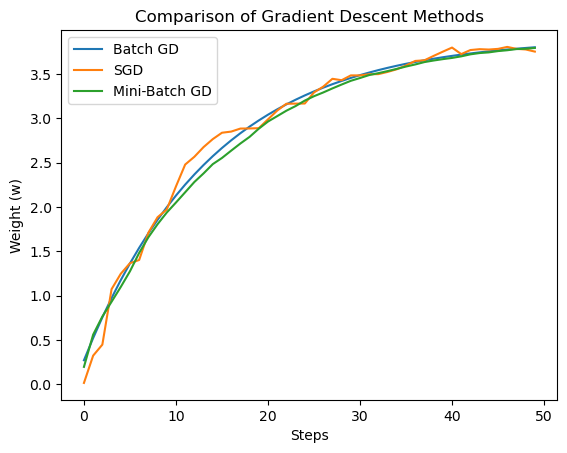

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic linear data
np.random.seed(42)
X = np.linspace(0, 10, 100)
y = 3*X + 7 + np.random.randn(100) * 2   # true line: 3x + 7 with noise

# Function to compute gradient
def compute_gradient(w, b, X, y):
    n = len(X)
    y_pred = w*X + b
    dw = (2/n) * np.sum((y_pred - y) * X)
    db = (2/n) * np.sum(y_pred - y)
    return dw, db

# Batch Gradient Descent
def batch_gd(X, y, lr=0.001, steps=50):
    w, b = 0.0, 0.0
    history = []
    for _ in range(steps):
        dw, db = compute_gradient(w, b, X, y)
        w -= lr * dw
        b -= lr * db
        history.append((w, b))
    return history

# Stochastic Gradient Descent (SGD)
def sgd(X, y, lr=0.001, steps=50):
    w, b = 0.0, 0.0
    history = []
    for _ in range(steps):
        i = np.random.randint(0, len(X))  # pick 1 random point
        dw, db = compute_gradient(w, b, X[i:i+1], y[i:i+1])
        w -= lr * dw
        b -= lr * db
        history.append((w, b))
    return history

# Mini-Batch Gradient Descent
def minibatch_gd(X, y, lr=0.001, steps=50, batch_size=20):
    w, b = 0.0, 0.0
    history = []
    for _ in range(steps):
        idx = np.random.choice(len(X), batch_size, replace=False)
        dw, db = compute_gradient(w, b, X[idx], y[idx])
        w -= lr * dw
        b -= lr * db
        history.append((w, b))
    return history

# Run all methods
batch_history = batch_gd(X, y)
sgd_history = sgd(X, y)
minibatch_history = minibatch_gd(X, y)

# Plot convergence of weight w
plt.plot([w for w,b in batch_history], label="Batch GD")
plt.plot([w for w,b in sgd_history], label="SGD")
plt.plot([w for w,b in minibatch_history], label="Mini-Batch GD")
plt.xlabel("Steps")
plt.ylabel("Weight (w)")
plt.title("Comparison of Gradient Descent Methods")
plt.legend()
plt.show()
